In [7]:
import os 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

from DCGAN.vectorized_unet import VectorizedUNet
from DCGAN.unet import UNet

from CityScapes.datasets import CityScapesMultiResolutionDataset
from DCGAN.loss_functions import GradientPenaltyLoss, EntropyLoss, DriftLoss, WeightedMSELoss, TotalVariationLoss

device ="cuda" if torch.cuda.is_available() else "cpu"
scale_for_display = lambda x: x.mul(0.5).add(0.5)

In [ ]:

msg_dataset = CityScapesMultiResolutionDataset()
train_loader = DataLoader(msg_dataset, batch_size=batch_size, shuffle=True)


Dataset initialized with 19998 samples. Labels enabled: False


Epoch 0 | Patch MSE Loss: 0.0158


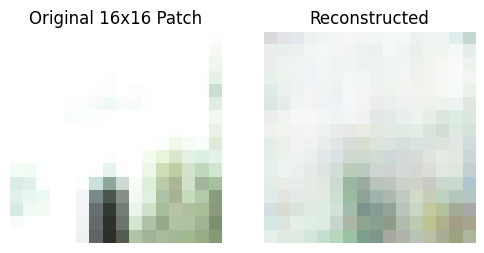

Epoch 2/20:  25%|██▌       | 626/2500 [00:10<00:30, 62.45it/s, loss=0.00652] 


KeyboardInterrupt: 

In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Import your custom modules
from DCGAN.modules.blocks.eq_lr_layers import EQLRConv2d
from DCGAN.modules.residual_block import ResidualBlock
from DCGAN.modules.blocks.spatial_vectorizer import SpatialVectorizer

class PatchReconstructor(nn.Module):
    def __init__(self, in_channels=3, features=64, n_components=1, dof=64, grid_size=16):
        super().__init__()
        # 1. Residual Block (kernel=3 via your ConvBlock defaults, maintains 16x16)
        self.res = ResidualBlock(in_channels=in_channels, out_channels=features, depth=2)
        
        # 2. Vectorizer (grid_size=16 for a 16x16 patch means h_coarse=1, w_coarse=1)
        self.vec = SpatialVectorizer(
            in_channels=features, 
            out_channels=features, 
            number_of_components=n_components,
            degrees_of_freedom=dof, 
            grid_size=grid_size
        )
        
        # 3. 1x1 Conv to RGB 
        # Using EQLRConv2d directly instead of ConvBlock to avoid extra LeakyReLU/PixelNorm at the output
        self.to_rgb = nn.Sequential(
            EQLRConv2d(in_channels=features, out_channels=3, kernel_size=1, stride=1, padding=0),
            nn.Tanh()
        )

    def forward(self, x):
        # x: (B, 3, 16, 16)
        feat = self.res(x)
        
        # vec_out: (B, N, C, 16, 16)
        vec_out = self.vec(feat)
        
        # Collapse the components dimension (N)
        combined_feat = vec_out.sum(dim=1) 
        
        # Map back to RGB
        rgb = self.to_rgb(combined_feat)
        return rgb

def extract_random_patches(images, patch_size=16):
    """Cuts random patch_size x patch_size squares from a batch of images."""
    b, c, h, w = images.shape
    patches = torch.empty((b, c, patch_size, patch_size), device=images.device)
    for i in range(b):
        y = torch.randint(0, h - patch_size + 1, (1,)).item()
        x = torch.randint(0, w - patch_size + 1, (1,)).item()
        patches[i] = images[i, :, y:y+patch_size, x:x+patch_size]
    return patches

# Initialize the test module
# Start with 1 component and e.g., 64 DoF to test baseline capacity

grid_size = 16
model = PatchReconstructor(features=64, n_components=1, dof=64, grid_size=grid_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

print("Starting Patch Capacity Test...")
epochs = 20
for epoch in range(epochs):
    total_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
    for batch in loop:
        # Handle your msgdataset nested tuple/list structure to grab the highest res images
        if isinstance(batch, (list, tuple)):
            images = batch[0][-1] if isinstance(batch[0], list) else batch[0]
        else:
            images = batch
            
        images = images.to(device)
        
        # Cut random 16x16 patches for this step
        patches = extract_random_patches(images, patch_size=grid_size)
        
        optimizer.zero_grad()
        reconstructed = model(patches)
        
        # We use MSE to measure exact pixel-level information retention
        loss = F.mse_loss(reconstructed, patches)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    avg_loss = total_loss / len(train_loader)

    # Visualize every 10 epochs
    if epoch % 10 == 0:
        clear_output(wait=True)
        print(f"Epoch {epoch} | Patch MSE Loss: {avg_loss:.4f}")
        
        # Show the first patch in the batch
        plt.figure(figsize=(6, 3))
        
        plt.subplot(1, 2, 1)
        plt.title("Original 16x16 Patch")
        # De-normalize from [-1, 1] to [0, 1] for display
        orig_img = patches[0].permute(1, 2, 0).cpu().detach() * 0.5 + 0.5
        plt.imshow(orig_img.clamp(0, 1))
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.title("Reconstructed")
        rec_img = reconstructed[0].permute(1, 2, 0).cpu().detach() * 0.5 + 0.5
        plt.imshow(rec_img.clamp(0, 1))
        plt.axis('off')
        
        plt.show()


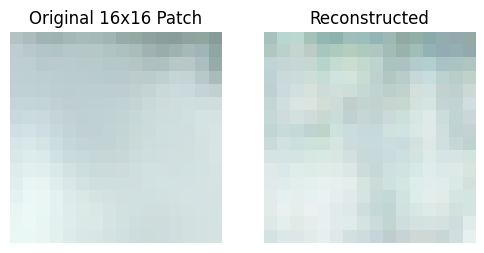

tensor(0.0108, device='cuda:0')


In [86]:
clear_output(wait=True)
# print(f"Epoch {epoch} | Patch MSE Loss: {avg_loss:.4f}")

batch = next(iter(train_loader))
# Handle your msgdataset nested tuple/list structure to grab the highest res images
if isinstance(batch, (list, tuple)):
    images = batch[0][-1] if isinstance(batch[0], list) else batch[0]
else:
    images = batch
    

# Cut random 16x16 patches for this step
patches = extract_random_patches(images, patch_size=16)
with torch.no_grad():
    patches = patches.to(device)
    reconstructed = model(patches)

# Show the first patch in the batch
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title("Original 16x16 Patch")
# De-normalize from [-1, 1] to [0, 1] for display
orig_img = patches[0].permute(1, 2, 0).cpu().detach() * 0.5 + 0.5
plt.imshow(orig_img.clamp(0, 1))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed")
rec_img = reconstructed[0].permute(1, 2, 0).cpu().detach() * 0.5 + 0.5
plt.imshow(rec_img.clamp(0, 1))
plt.axis('off')

plt.show()

print(nn.MSELoss()(reconstructed, patches))